In [203]:
%matplotlib inline
import mne

mne.set_config('MNE_BROWSER_BACKEND', 'matplotlib')
mne.viz.set_browser_backend('matplotlib')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from mne.preprocessing import ICA
# import pandas as pd

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parent
print(dir)

if dir not in sys.path:
    sys.path.append(str(dir))  


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
C:\Users\LENOVO\henry\research\final_thesis\eeg-emotion-analysis


### Data Extraction

In [204]:
dens_dir = dir / "data" / "DENS"
gameemo_dir = dir / "data" / "GAMEEMO"

dens_subdirs = [p for p in dens_dir.iterdir() if p.is_dir()]
gameemo_subdirs = [p for p in dens_dir.iterdir() if p.is_dir()]

# remove .datalad and gameplay folders
del dens_subdirs[0]
del gameemo_subdirs[-1]

dens_subj_003_path = dens_subdirs[0] / "eeg" / "sub-mit003_task-Emotion_eeg.set"
dens_subj_004_path = dens_subdirs[1] / "eeg" / "sub-mit004_task-Emotion_eeg.set"

In [205]:
# trial subject data extraction
raw_003_dens = mne.io.read_raw_eeglab(dens_subj_003_path, preload=True)
raw_004_dens = mne.io.read_raw_eeglab(dens_subj_004_path, preload=True)

print(raw_003_dens.ch_names[-10:])
print(raw_004_dens.ch_names[-10:])

# based the metadata description in the JSON, the montage type follows GSN-HydroCel-129 settings
raw_003_dens.set_channel_types({"ECG" : "ecg", "EMG" : "emg", "EMG_2" : "emg"})
raw_003_dens.rename_channels({"E129": "Cz"})

raw_003_dens.set_montage(mne.channels.make_standard_montage("GSN-HydroCel-129"), match_case=False)

raw_004_dens.set_channel_types({"ECG" : "ecg", "EMG" : "emg", "EMG_2" : "emg"})
raw_004_dens.rename_channels({"E129": "Cz"})

raw_004_dens.set_montage(mne.channels.make_standard_montage("GSN-HydroCel-129"), match_case=False)
raw_004_dens

Reading C:\Users\LENOVO\henry\research\final_thesis\eeg-emotion-analysis\data\DENS\sub-mit003\eeg\sub-mit003_task-Emotion_eeg.fdt
Reading 0 ... 674089  =      0.000 ...  2696.356 secs...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11828\2727746575.py:2: RuntimeWarning: Unknown types found, setting as type EEG:
pns: ['ECG', 'EMG', 'EMG_2']
  raw_003_dens = mne.io.read_raw_eeglab(dens_subj_003_path, preload=True)


Reading C:\Users\LENOVO\henry\research\final_thesis\eeg-emotion-analysis\data\DENS\sub-mit004\eeg\sub-mit004_task-Emotion_eeg.fdt
Reading 0 ... 430526  =      0.000 ...  1722.104 secs...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11828\2727746575.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_003_dens = mne.io.read_raw_eeglab(dens_subj_003_path, preload=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11828\2727746575.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
pns: ['ECG', 'EMG', 'EMG_2']
  raw_004_dens = mne.io.read_raw_eeglab(dens_subj_004_path, preload=True)


['E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129', 'ECG', 'EMG', 'EMG_2']
['E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129', 'ECG', 'EMG', 'EMG_2']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11828\2727746575.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_004_dens = mne.io.read_raw_eeglab(dens_subj_004_path, preload=True)


<RawEEGLAB | sub-mit004_task-Emotion_eeg.fdt, 132 x 430527 (1722.1 s), ~433.7 MiB, data loaded>

In [206]:
raw_003_dens

<RawEEGLAB | sub-mit003_task-Emotion_eeg.fdt, 132 x 674090 (2696.4 s), ~679.0 MiB, data loaded>

In [207]:
ecg_data = raw_003_dens.copy().pick_types(ecg=True).get_data()
emg_data = raw_003_dens.copy().pick_types(emg=True).get_data()
eeg_data = raw_003_dens.copy().pick_types(eeg=True).get_data()

ecg_data_04 = raw_004_dens.copy().pick_types(ecg=True).get_data()
emg_data_04 = raw_004_dens.copy().pick_types(emg=True).get_data()
eeg_data_04 = raw_004_dens.copy().pick_types(eeg=True).get_data()

print("EEG before scaling:", eeg_data.max(), eeg_data.min())
print("EMG before scaling:", emg_data.max(), emg_data.min())
print("ECG before scaling:", ecg_data.max(), ecg_data.min())
print("=" * 50)
print("EEG before scaling:", eeg_data_04.max(), eeg_data_04.min())
print("EMG before scaling:", emg_data_04.max(), emg_data_04.min())
print("ECG before scaling:", ecg_data_04.max(), ecg_data_04.min())

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
EEG before scaling: 0.33328625 -0.33319296875
EMG before scaling: 0.019062060546875 -0.1148899375
ECG before scaling: 0.018257830078125 -0.016384326171874998
EEG before scaling: 0.016290806640625 -0.10548878906249999
EMG before scaling: 0.01561109765625 -0.013976078125
ECG before scaling: 0.00699456591796875 -0.0065247333984375


In [208]:
print(raw_003_dens.filenames)
print(raw_004_dens.filenames)

(WindowsPath('C:/Users/LENOVO/henry/research/final_thesis/eeg-emotion-analysis/data/DENS/sub-mit003/eeg/sub-mit003_task-Emotion_eeg.fdt'),)
(WindowsPath('C:/Users/LENOVO/henry/research/final_thesis/eeg-emotion-analysis/data/DENS/sub-mit004/eeg/sub-mit004_task-Emotion_eeg.fdt'),)


In [185]:
eeg_picks = mne.pick_types(raw_003_dens.info, eeg=True)
raw_003_dens._data[eeg_picks] /= 1000

# re-check
eeg_data = raw_003_dens.copy().pick_types(eeg=True).get_data()
print("EEG after scaling:", eeg_data.max(), eeg_data.min())

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
EEG after scaling: 1.6290806640625e-05 -0.0001054887890625


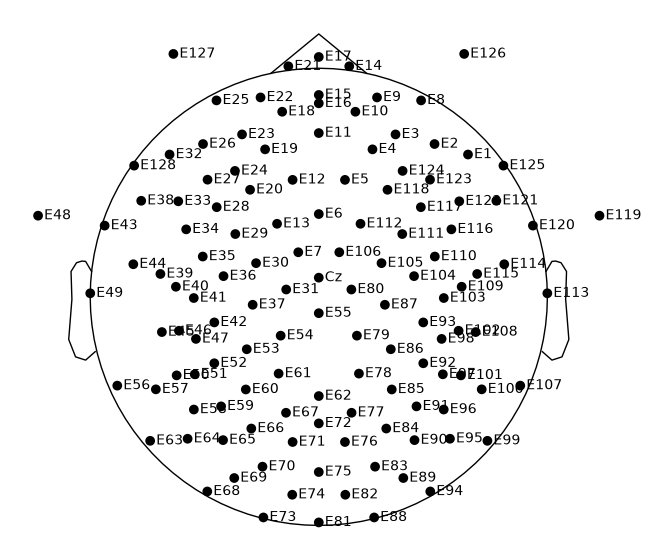

Figure(640x640)


In [147]:
# visualize the EEG placements
print(raw_003_dens.plot_sensors(show_names=True))

### Basic Preprocessing & Filtering

In [148]:
raw_003_dens.set_eeg_reference(ref_channels="average")
dens_003 = raw_003_dens.copy()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


In [149]:
print(dens_003.get_data().max(), dens_003.get_data().min())

0.021790199067344966 -0.09428329919563706


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


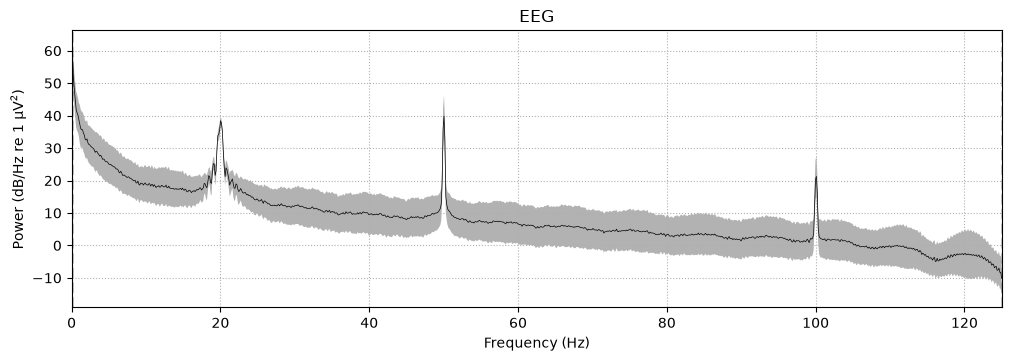

In [117]:
# since the DENS dataset contains other than EEG channels, we could assume there are other noise or artifacts contained
# in the raw EEG signal

# therefore, we need to handle these artifacts, power-line, noises.
fig = dens_003.compute_psd(tmax=np.inf, fmax=125).plot(
  average=True, amplitude=False, picks="data", exclude="bads"
)

# add some arrows at 60 Hz and its harmonics:
for ax in fig.axes[1:]:
    freqs = ax.lines[-1].get_xdata()
    psds = ax.lines[-1].get_ydata()
    for freq in (60, 120, 180, 240):
        idx = np.searchsorted(freqs, freq)
        ax.arrow(
            x=freqs[idx],
            y=psds[idx] + 18,
            dx=0,
            dy=-12,
            color="red",
            width=0.1,
            head_width=3,
            length_includes_head=True,
        )

#### Note 

From the plot, we can see there is a spike in the 40-60 Hz range. It's strongly suggest the presence of a power line artifact activity sitting in the 50Hz freq just as the metadata describes.

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoffs at 1.00, 40.00 Hz: -6.02, -6.02 dB



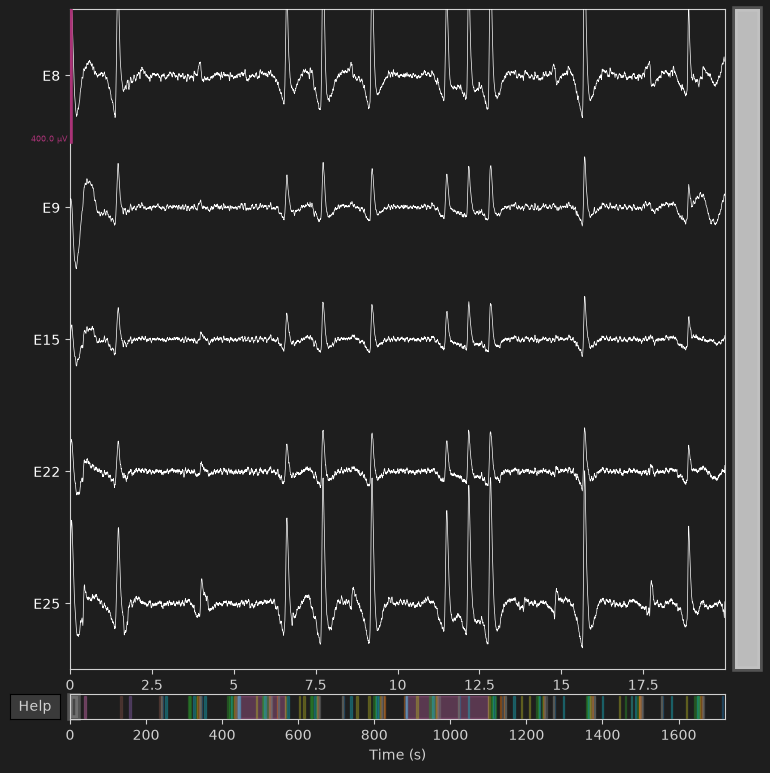

Figure(800x800)


In [139]:
# apply butterworth filtering with order 2 with band between 1 Hz and 40 Hz (standard treatment)
# this would isolate frequency regions that we are interested
iir_params = dict(order=2, ftype='butter')
dens_003.filter(l_freq=1.0, h_freq=40.0, method='iir', iir_params=iir_params, verbose=True)

# analyze the electrodes on frontal lobe area
channels = ["E25", "E22", "E15", "E9", "E8"]

print(dens_003.plot(
  duration=20,
  n_channels=len(channels),
  picks=channels,
  scalings=dict(eeg=200e-6),  
  clipping=1.5                 
))

#### Ocular Activity (EOG Artifact)

Using EOG channels: E25, E8, E11, E6, Cz
EOG channel index for this subject is: [ 24   7  10   5 128]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel E8 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 8 significant peaks
Number of EOG events detected: 8
Not setting metadata
8 matching events found
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 8 events and 251 original time points ...
1 bad epochs 

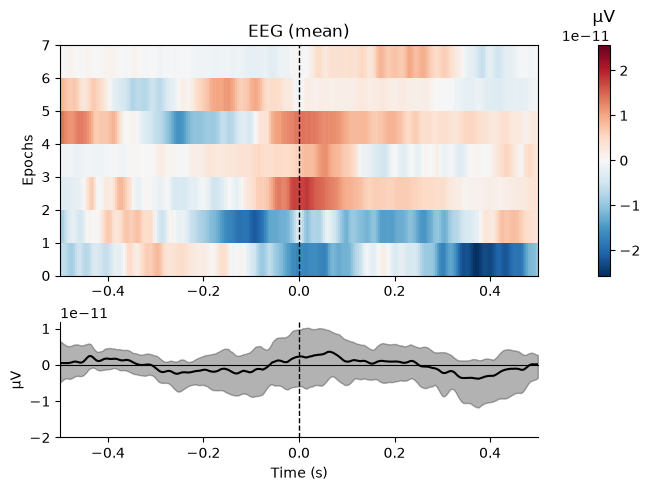

[<Figure size 640x480 with 3 Axes>]
No projector specified for this dataset. Please consider the method self.add_proj.


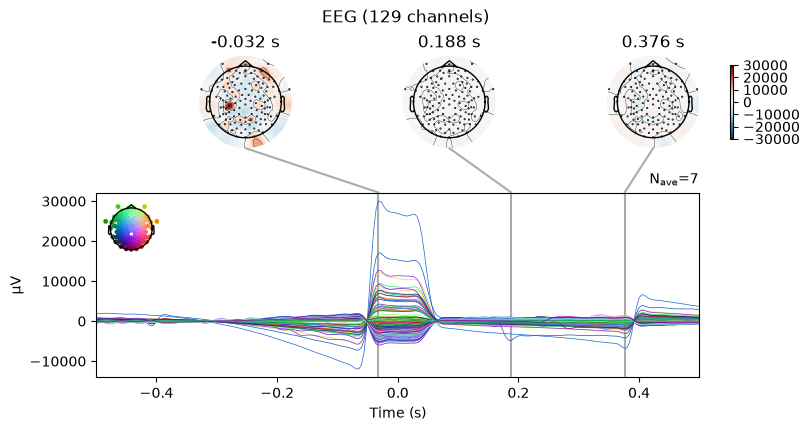

Figure(800x420)


In [141]:
eog_epochs = mne.preprocessing.create_eog_epochs(dens_003, ch_name=['E25','E8','E11','E6','Cz'], baseline=(-0.5, -0.2))
print(eog_epochs.plot_image(combine="mean"))
print(eog_epochs.average().plot_joint())

#### Note

The spikes observed in the plot strongly suggest the presence of physiological artifacts, such as eye blinks, muscle movements, and cardiac activity.

In [62]:
# no bad channels available
dens_003.info["bads"]

[]

#### Artifact & Noise Removal Using ICA

In [63]:
ica = ICA(n_components=15, max_iter="auto", rng=97)
ica.fit(dens_003)

Fitting ICA to data using 129 channels (please be patient, this may take a while)


Selecting by number: 15 components
Fitting ICA took 27.3s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,58 iterations on raw data (430527 samples)
ICA components,15
Available PCA components,129
Channel types,eeg
ICA components marked for exclusion,—


In [64]:
explained_var_ratio = ica.get_explained_variance_ratio(dens_003)
for channel_type, ratio in explained_var_ratio.items():
    print(f"Fraction of {channel_type} variance explained by all components: {ratio}")

Fraction of eeg variance explained by all components: 0.9777015849436441


In [65]:
explained_var_ratio = ica.get_explained_variance_ratio(
    dens_003, components=[0], ch_type="eeg"
)

ratio_percent = round(100 * explained_var_ratio["eeg"])
print(
    f"Fraction of variance in EEG signal explained by first component: {ratio_percent}%"
)

Fraction of variance in EEG signal explained by first component: 34%


Creating RawArray with float64 data, n_channels=16, n_times=430527
    Range : 0 ... 430526 =      0.000 ...  1722.104 secs
Ready.


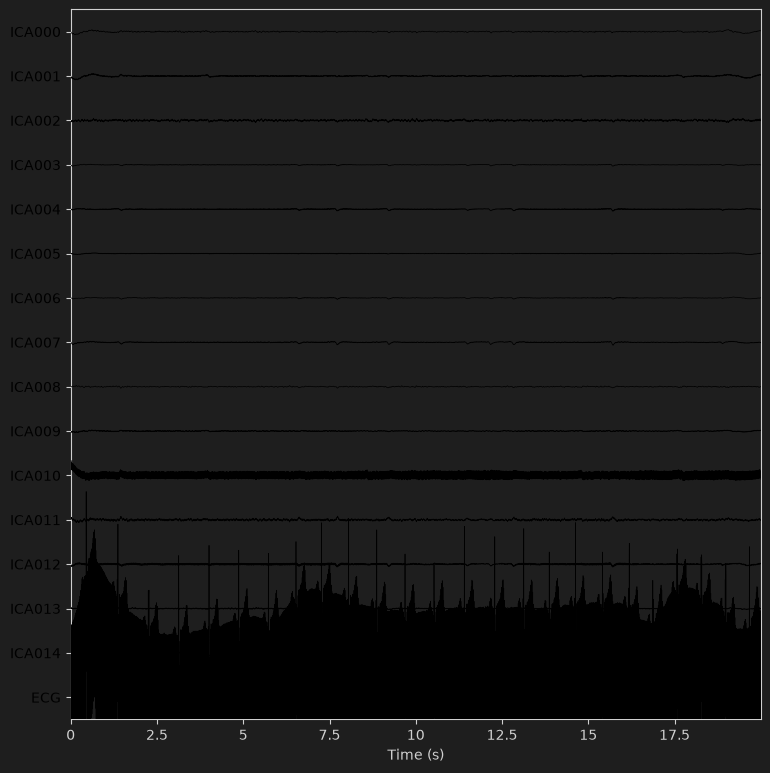

Figure(800x800)


In [66]:
print(ica.plot_sources(dens_003, show_scrollbars=False))